Real-Life Project: NLP & Sentiment Analysis
Online Review Sentiment Analysis — Flipkart / Twitter


In [1]:
# import required libraries

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

!pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries ready.


In [3]:
#load dataset
df = pd.read_csv('online_reviews_sentiment.csv', parse_dates=['date'])
print(df.shape)
df.head()

(1000, 7)


,review_id,review_text,product,sentiment,source,date,rating
0,1,"Excellent build quality on this Yoga Mat, usin...",Yoga Mat,positive,Flipkart,2025-11-25,3
1,2,"Best Power Bank I have ever bought, highly rec...",Power Bank,positive,Flipkart,2025-07-14,3
2,3,I'm impressed by how well this Wireless Earbud...,Wireless Earbuds,positive,Flipkart,2025-04-12,5
3,4,"Best Bluetooth Speaker I have ever bought, hig...",Bluetooth Speaker,positive,Flipkart,2025-05-01,3
4,5,"The Power Bank exceeded my expectations, fast ...",Power Bank,positive,Flipkart,2025-02-14,3


In [4]:
print(df['sentiment'].value_counts())
print()
print(df['source'].value_counts())

sentiment
positive    400
negative    340
neutral     260
Name: count, dtype: int64

source
Flipkart    600
Twitter     400
Name: count, dtype: int64


In [6]:
#Tokenisation 
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)          # remove URLs, mentions, hashtag symbol
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(5)

,review_text,clean_text
0,"Excellent build quality on this Yoga Mat, usin...",excellent build quality yoga mat using daily w...
1,"Best Power Bank I have ever bought, highly rec...",best power bank ever bought highly recommend e...
2,I'm impressed by how well this Wireless Earbud...,im impressed well wireless earbuds performs buy
3,"Best Bluetooth Speaker I have ever bought, hig...",best bluetooth speaker ever bought highly reco...
4,"The Power Bank exceeded my expectations, fast ...",power bank exceeded expectations fast delivery


In [7]:
# TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("Sample vocabulary:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (1000, 1017)
Sample vocabulary: ['excellent', 'build', 'quality', 'yoga', 'mat', 'using', 'daily', 'without', 'issues', 'excellent build', 'build quality', 'quality yoga', 'yoga mat', 'mat using', 'using daily']


In [8]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 800  Test size: 200


###
Model selection and implementation
Logistic Regression
Multinomial Naive Bayes 
Linear SVM
###

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


In [11]:
#model evaluation and comparison
results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
2,Linear SVM,1.0,1.0,1.0,1.0


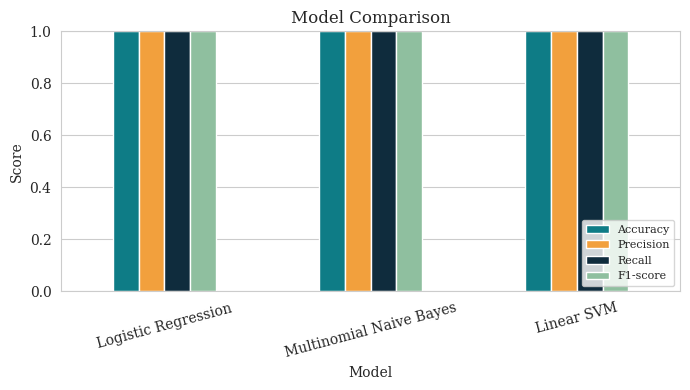

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot.bar(ax=ax, color=['#0E7C86','#F2A03D','#0F2C3D','#8FBF9F'])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Best model: Logistic Regression

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        68
     neutral       1.00      1.00      1.00        52
    positive       1.00      1.00      1.00        80

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



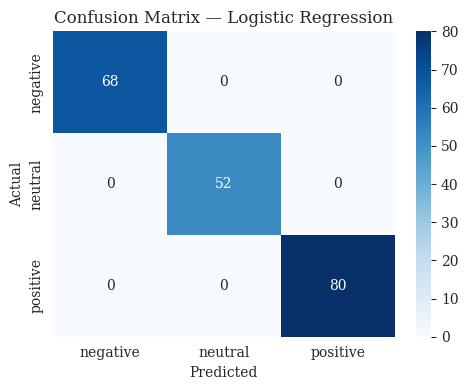

In [15]:
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
preds = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion.png")
plt.show()

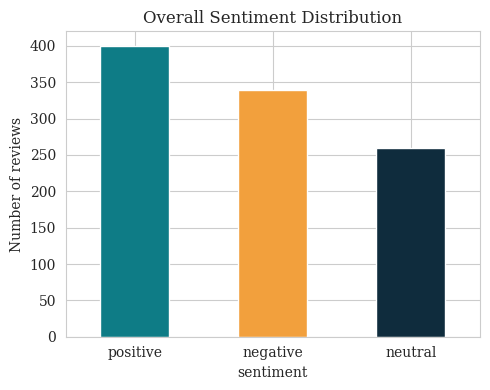

In [16]:
#visualise sentiment 
sent_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5,4))
sent_counts.plot.bar(color=['#0E7C86','#F2A03D','#0F2C3D'])
plt.title("Overall Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("overall_sentiment.png")
plt.show()

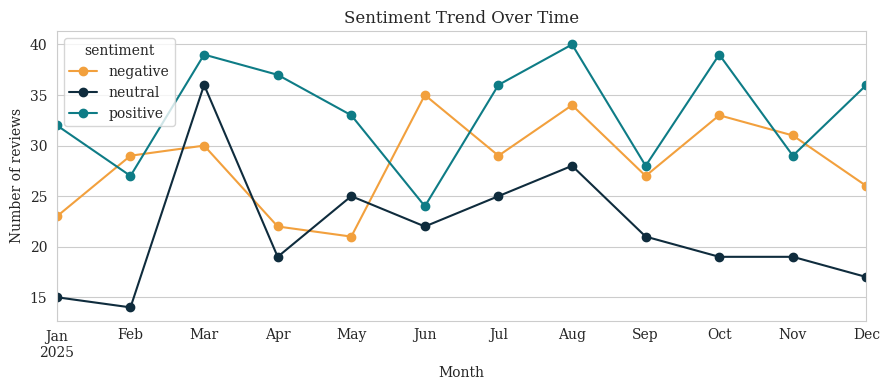

In [17]:
monthly = df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size().unstack(fill_value=0)
monthly.plot(figsize=(9,4), marker='o', color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Trend Over Time")
plt.ylabel("Number of reviews")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("trend_over_time.png")
plt.show()

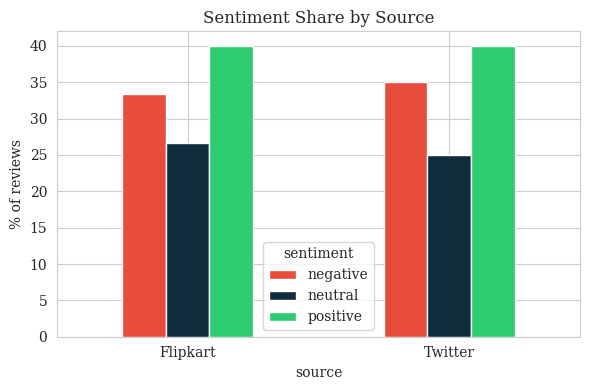

In [19]:
#sentiment by source
source_sentiment = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
source_sentiment.plot.bar(figsize=(6,4), color=['#E74C3C','#0F2C3D','#2ECC71'])
plt.title("Sentiment Share by Source")
plt.ylabel("% of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("senti_source.png")
plt.show()